In [2]:
import astropy
from astropy.io import fits
import bagpipes as pipes
import pathlib
import os
import numpy as np

Bagpipes: Latex turned off in rcParams, plots may look strange.


In [3]:
JADES_File_Path = pathlib.Path('../JADES/catalogs').expanduser()

In [4]:
for file in JADES_File_Path.glob('*.fits'):
    with astropy.io.fits.open(file) as hdul:
        data = hdul[5].data
        print(hdul.info())

Filename: ../JADES/catalogs/hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      63   ()      
  1  FILTERS       1 BinTableHDU     83   27R x 12C   [6A, E, E, E, E, E, E, E, E, E, E, E]   
  2  FLAG          1 BinTableHDU    308   181144R x 87C   [K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
  3  SIZE          1 BinTableHDU    101   181144R x 18C   [J, D, D, D, D, D, D, K, K, K, K, D, D, D, D, D, D, D]   
  4  CIRC          1 BinTableHDU   1631   181144R x 528C   [J, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E

In [5]:
fits_path = '../JADES/catalogs/hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog.fits'

In [6]:
import os
from astropy.io import fits

# 1. 设置路径
filter_dir = "my_filters"
current_dir = os.getcwd()

# 2. 从 FITS 文件中获取原始波段顺序（非常重要，必须对应）
with fits.open(fits_path) as hdul:
    # 假设 hdul[1] 是滤光片信息表
    raw_filter_names = hdul[1].data["BAND"]
    # 转换为字符串并统一大写
    raw_filter_names = [str(n).upper() for n in raw_filter_names]

# 3. 扫描本地文件夹，只保留下载成功的滤光片
valid_filter_names = []
valid_filter_paths = []

print("正在同步本地滤光片文件...")

for name in raw_filter_names:
    # 检查本地是否存在对应的 .res 文件
    res_file = f"{name}.res"
    res_path = os.path.join(current_dir, filter_dir, res_file)

    if os.path.exists(res_path):
        valid_filter_names.append(name)
        valid_filter_paths.append(res_path)
        print(f"✅ 已加载本地文件: {res_file}")
    else:
        # 这些通常是之前下载失败的 HST 波段或特殊波段
        print(f"⚠️ 跳过(本地无文件): {name}")

print(f"\n同步完成！共计 {len(valid_filter_names)} 个有效滤光片。")
print(f"有效列表名称: {valid_filter_names}")

正在同步本地滤光片文件...
✅ 已加载本地文件: F070W.res
✅ 已加载本地文件: F090W.res
✅ 已加载本地文件: F115W.res
✅ 已加载本地文件: F150W.res
✅ 已加载本地文件: F162M.res
✅ 已加载本地文件: F182M.res
✅ 已加载本地文件: F200W.res
✅ 已加载本地文件: F210M.res
✅ 已加载本地文件: F277W.res
✅ 已加载本地文件: F300M.res
✅ 已加载本地文件: F335M.res
✅ 已加载本地文件: F356W.res
✅ 已加载本地文件: F410M.res
✅ 已加载本地文件: F430M.res
✅ 已加载本地文件: F444W.res
✅ 已加载本地文件: F460M.res
✅ 已加载本地文件: F770W.res
✅ 已加载本地文件: F1280W.res
✅ 已加载本地文件: F435W.res
✅ 已加载本地文件: F606W.res
✅ 已加载本地文件: F775W.res
✅ 已加载本地文件: F814W.res
✅ 已加载本地文件: F850LP.res
✅ 已加载本地文件: F105W.res
✅ 已加载本地文件: F125W.res
✅ 已加载本地文件: F140W.res
✅ 已加载本地文件: F160W.res

同步完成！共计 27 个有效滤光片。
有效列表名称: ['F070W', 'F090W', 'F115W', 'F150W', 'F162M', 'F182M', 'F200W', 'F210M', 'F277W', 'F300M', 'F335M', 'F356W', 'F410M', 'F430M', 'F444W', 'F460M', 'F770W', 'F1280W', 'F435W', 'F606W', 'F775W', 'F814W', 'F850LP', 'F105W', 'F125W', 'F140W', 'F160W']


In [7]:
import os
from astropy.io import fits

filter_dir = "my_filters"
current_dir = os.getcwd()

# 1. 获取 FITS 表中所有的列名
with fits.open(fits_path) as hdul:
    all_columns = hdul[5].columns.names  # 获取所有列名
    raw_bands = hdul[1].data["BAND"]     # 获取原始波段名
    raw_bands = [str(n).upper() for n in raw_bands]

# 2. 重新生成有效清单
final_valid_names = []
final_valid_paths = []

print("正在严格对齐本地文件与 FITS 列名...")

for name in raw_bands:
    res_path = os.path.join(current_dir, filter_dir, f"{name}.res")

    # 检查 A: 本地是否有 .res 文件
    file_exists = os.path.exists(res_path)

    # 检查 B: FITS 表里是否有对应的 CIRC3 列
    # 如果是 MIRI 波段（F770W及以上），CIRC3 可能不存在，尝试匹配其他列
    circ_col = f"{name}_CIRC3"
    col_exists = circ_col in all_columns

    if file_exists and col_exists:
        final_valid_names.append(name)
        final_valid_paths.append(res_path)
        print(f"✅ 匹配成功: {name} (使用列 {circ_col})")
    elif file_exists and not col_exists:
        # 如果有文件但没 CIRC3，检查是否有基础 FLUX 列
        if f"{name}_FLUX" in all_columns:
            # 这里你可以决定是否使用基础 FLUX 列，或者干脆跳过
            # 建议跳过以保持所有波段孔径一致性
            print(f"⚠️ 跳过: {name} (本地有文件但表中无 _CIRC3 列)")
        else:
            print(f"❌ 跳过: {name} (表中完全找不到该波段数据)")
    else:
        print(f"⚠️ 跳过: {name} (本地无 .res 文件)")

print(f"\n对齐完成！最终参与拟合的波段数量: {len(final_valid_names)}")

正在严格对齐本地文件与 FITS 列名...
✅ 匹配成功: F070W (使用列 F070W_CIRC3)
✅ 匹配成功: F090W (使用列 F090W_CIRC3)
✅ 匹配成功: F115W (使用列 F115W_CIRC3)
✅ 匹配成功: F150W (使用列 F150W_CIRC3)
✅ 匹配成功: F162M (使用列 F162M_CIRC3)
✅ 匹配成功: F182M (使用列 F182M_CIRC3)
✅ 匹配成功: F200W (使用列 F200W_CIRC3)
✅ 匹配成功: F210M (使用列 F210M_CIRC3)
✅ 匹配成功: F277W (使用列 F277W_CIRC3)
✅ 匹配成功: F300M (使用列 F300M_CIRC3)
✅ 匹配成功: F335M (使用列 F335M_CIRC3)
✅ 匹配成功: F356W (使用列 F356W_CIRC3)
✅ 匹配成功: F410M (使用列 F410M_CIRC3)
✅ 匹配成功: F430M (使用列 F430M_CIRC3)
✅ 匹配成功: F444W (使用列 F444W_CIRC3)
✅ 匹配成功: F460M (使用列 F460M_CIRC3)
❌ 跳过: F770W (表中完全找不到该波段数据)
❌ 跳过: F1280W (表中完全找不到该波段数据)
✅ 匹配成功: F435W (使用列 F435W_CIRC3)
✅ 匹配成功: F606W (使用列 F606W_CIRC3)
✅ 匹配成功: F775W (使用列 F775W_CIRC3)
✅ 匹配成功: F814W (使用列 F814W_CIRC3)
✅ 匹配成功: F850LP (使用列 F850LP_CIRC3)
✅ 匹配成功: F105W (使用列 F105W_CIRC3)
✅ 匹配成功: F125W (使用列 F125W_CIRC3)
✅ 匹配成功: F140W (使用列 F140W_CIRC3)
✅ 匹配成功: F160W (使用列 F160W_CIRC3)

对齐完成！最终参与拟合的波段数量: 25


In [8]:
from numpy import argsort


with fits.open(fits_path) as hdul:
    circ_data = hdul[5].data
    photoz_data = hdul[11].data

    # 1. 建立ID映射
    id_circ = circ_data["ID"].astype(int)
    id_photoz = photoz_data["ID"].astype(int)
    common_ids, idx_c, idx_p = np.intersect1d(id_circ, id_photoz, return_indices=True)

    # 2. 准备计算所有有效波段的 SNR
    # final_valid_names 是你之前对齐好的滤光片列表
    all_snrs = []
    for band in final_valid_names:
        f = circ_data[f"{band}_CIRC3"][idx_c]
        e = circ_data[f"{band}_CIRC3_e"][idx_c]
        all_snrs.append(f / (e + 1e-8))

    snr_array = np.array(all_snrs) # 形状: (波段数, 星系数)

    # 3. 筛选准则：
    # - 官方红移在 3 < z < 7 (确保 Lyman break 在观测范围内)
    # - 计算有多少个波段的 SNR > 15
    # - 计算这些波段的平均 SNR
    z_ml = photoz_data["z_ml"][idx_p]
    z_mask = (z_ml > 3) & (z_ml < 7)

    # 统计每个星系有多少个波段 SNR > 5
    high_snr_count = np.nansum(snr_array > 5, axis=0)
    # 计算所有波段的平均 SNR
    mean_snr = np.nansum(snr_array, axis=0) / 25

    # 综合评分：优先考虑高 SNR 波段数量多的，其次看平均 SNR
    score = high_snr_count * 100 + mean_snr

    # 在符合红移范围的星系中找分值最高的
    max_score_ids=np.sort(score[z_mask])
    ids=np.argsort(score[z_mask])[::-1]  # 获取分值最高的前5个星系的分数

    best_idx = ids[1009]

    target_id = int(common_ids[z_mask][best_idx])
    target_z = z_ml[z_mask][best_idx]

    print(f"🌟 找到多波段高质量星系 ID: {target_id}")
    print(f"📊 官方红移估算: {target_z:.3f}")
    print(f"🔥 SNR > 5 的波段数量: {high_snr_count[z_mask][best_idx]}")
    print(f"📈 平均信噪比: {mean_snr[z_mask][best_idx]:.2f}")



    # # 打印前 5 个 SNR 最好的波段
    # sorted_snr_indices = np.argsort(snr_array[:,z_mask][:, best_idx])[::-1]
    # print("各波段表现：")
    # for i in sorted_snr_indices[:5]:
    #     print(f"   {final_valid_names[i]}: SNR = {snr_array[:,z_mask][i, best_idx]:.2f}")

🌟 找到多波段高质量星系 ID: 1055286
📊 官方红移估算: 3.376
🔥 SNR > 5 的波段数量: 19
📈 平均信噪比: 18.83


In [9]:
def load_jades_multi_high(ID):
    # 提取数字 ID
    numeric_id = int(''.join(filter(str.isdigit, str(ID))))

    with fits.open(fits_path) as hdul:
        data = hdul[5].data
        ids_in_table = data["ID"].astype(int)
        idx = np.where(ids_in_table == numeric_id)[0][0]

        fluxes, errors = [], []
        for band in final_valid_names:
            col_f, col_e = f"{band}_CIRC3", f"{band}_CIRC3_e"

            # nJy -> uJy
            f_uJy = data[col_f][idx] / 1000.0
            e_uJy = data[col_e][idx] / 1000.0

            fluxes.append(f_uJy)

            errors.append(e_uJy)

    return np.c_[fluxes, errors]

In [10]:
raw_data=load_jades_multi_high(target_id)

In [11]:
filters=[]
filters_path=[]
for i, name in enumerate(final_valid_names):
    if raw_data[i,0] > 0 and raw_data[i,1] > 0:
        filters.append(name)
        filters_path.append(os.path.join(current_dir, filter_dir, f"{name}.res"))



In [12]:
def load_solid_filters(id):
    raw_data=load_jades_multi_high(id)
    flux,err=[],[]
    for i, name in enumerate(final_valid_names):
        if name in filters:
            flux.append(raw_data[i,0])
            err.append(raw_data[i,1]+0.05*raw_data[i,0])
    return np.c_[flux, err]
#extra 5% noise

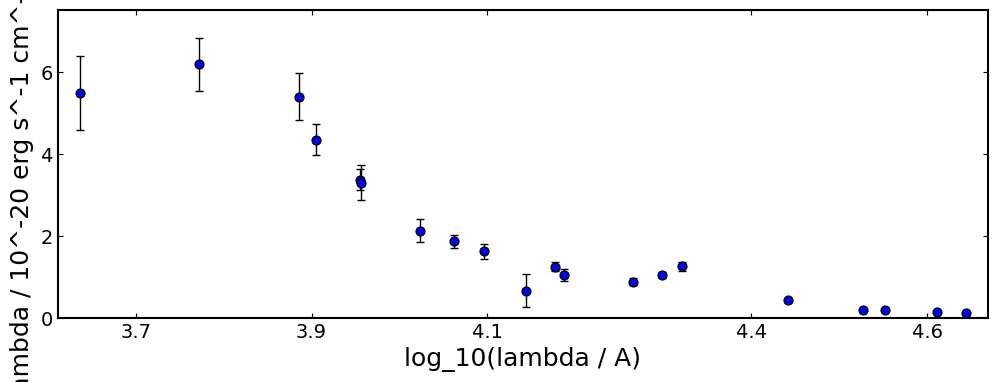

In [ ]:
fit_id = f"{target_id}"

# 2. 初始化 Galaxy
galaxy = pipes.galaxy(fit_id, load_solid_filters,
                      spectrum_exists=False,
                      filt_list=filters_path,phot_units="mujy", out_units="ergscma")
fig=galaxy.plot()

In [ ]:
redshift = target_z
from astropy.cosmology import Planck18 as cosmo

current_cosmic_age = cosmo.age(redshift).value  # 单位是 Gyr
max_age_form_stars=cosmo.age(redshift+0.3).value
max_age_form_stars

np.float64(1.6993695525020371)

In [ ]:
fit_instructions = {
    "redshift": (redshift - 0.2, redshift + 0.2), #+-0.3
    "delayed": {
        "tau":(0.001, 1.),
        "age": (0.01, max_age_form_stars),
        "massformed": (0.1, 12.),
        "metallicity": (0., 1.5)
    }, #only delayed tau
    # "constant": {
    #     "age_max": (0.01, max_age_form_stars),
    #     "age_min": (0.01, max_age_form_stars),
    #     "massformed": (0.1, 12.),
    #     "metallicity": (0., 1.5)
    #     },
    # "burst":{
    #     "age": (0.01, max_age_form_stars),
    #     "massformed": (0.1, 12.),
    #     "metallicity": (0., 1.5)
    # },
    "dust": {"type": "Calzetti", "Av": (0., 2.0)},
    "nebular": {
        "logU": (-3, -1)
    }
}


fit = pipes.fit(galaxy, fit_instructions)
fit.fit(verbose=False,sampler='nautilus')



Results loaded from pipes/posterior/./1055286.h5

Fitting not performed as results have already been loaded from pipes/posterior/./1055286.h5. To start over delete this file or change run.



In [17]:
pipes_fitted_path = pathlib.Path("./pipes/posterior")
import matplotlib.pyplot as plt
for filename in os.listdir(pipes_fitted_path):
    if filename.endswith(".h5"):
        id=filename.split(".h5")[0]

        def load_jades_multi_high(ID):
    # 提取数字 ID
            numeric_id = int(''.join(filter(str.isdigit, str(ID))))

            with fits.open(fits_path) as hdul:
                data = hdul[5].data
                ids_in_table = data["ID"].astype(int)
                idx = np.where(ids_in_table == numeric_id)[0][0]

                fluxes, errors = [], []
                for band in final_valid_names:
                    col_f, col_e = f"{band}_CIRC3", f"{band}_CIRC3_e"

                    # nJy -> uJy
                    f_uJy = data[col_f][idx] / 1000.0
                    e_uJy = data[col_e][idx] / 1000.0

                    fluxes.append(f_uJy)

                    errors.append(e_uJy)

            return np.c_[fluxes, errors]

        raw_data=load_jades_multi_high(id)
        filters=[]
        filters_path=[]
        for i, name in enumerate(final_valid_names):
            if raw_data[i,0] > 0 and raw_data[i,1] > 0:
                filters.append(name)
                filters_path.append(os.path.join(current_dir, filter_dir, f"{name}.res"))

        def load_solid_filters(id):
            raw_data=load_jades_multi_high(id)
            flux,err=[],[]
            for i, name in enumerate(final_valid_names):
                if name in filters:
                    flux.append(raw_data[i,0])
                    err.append(raw_data[i,1]+0.05*raw_data[i,0])
            return np.c_[flux, err]



        galaxy = pipes.galaxy(id, load_solid_filters,
                      spectrum_exists=False,
                      filt_list=filters_path,phot_units="mujy", out_units="ergscma")
        fit = pipes.fit(galaxy, fit_instructions)
        fit.fit(verbose=False,sampler='nautilus')
        fit.plot_spectrum_posterior()
        plt.show()
        fit.plot_sfh_posterior()
        fit.plot_corner()




Results loaded from pipes/posterior/./1211864.h5

Fitting not performed as results have already been loaded from pipes/posterior/./1211864.h5. To start over delete this file or change run.


Results loaded from pipes/posterior/./1146912.h5

Fitting not performed as results have already been loaded from pipes/posterior/./1146912.h5. To start over delete this file or change run.


Results loaded from pipes/posterior/./1161336.h5

Fitting not performed as results have already been loaded from pipes/posterior/./1161336.h5. To start over delete this file or change run.


Results loaded from pipes/posterior/./1220359.h5

Fitting not performed as results have already been loaded from pipes/posterior/./1220359.h5. To start over delete this file or change run.


Results loaded from pipes/posterior/./1055286.h5

Fitting not performed as results have already been loaded from pipes/posterior/./1055286.h5. To start over delete this file or change run.


Results loaded from pipes/posterior/./121840

In [24]:
fit.posterior.samples.keys()

dict_keys(['delayed:age', 'delayed:massformed', 'delayed:metallicity', 'delayed:tau', 'dust:Av', 'nebular:logU', 'redshift', 'stellar_mass', 'formed_mass', 'sfr', 'ssfr', 'nsfr', 'mass_weighted_age', 'tform', 'tquench', 'mass_weighted_zmet', 'sfh', 'photometry', 'spectrum_full', 'uvj', 'chisq_phot', 'dust_curve'])

In [51]:
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70., Om0=0.3)
z_array = np.arange(0., 100., 0.01)
age_at_z = cosmo.age(z_array).value
ldist_at_z = cosmo.luminosity_distance(z_array).value


In [52]:
redshift = np.median(fit.posterior.samples["redshift"])

In [57]:
age_of_universe = cosmo.age(redshift).value

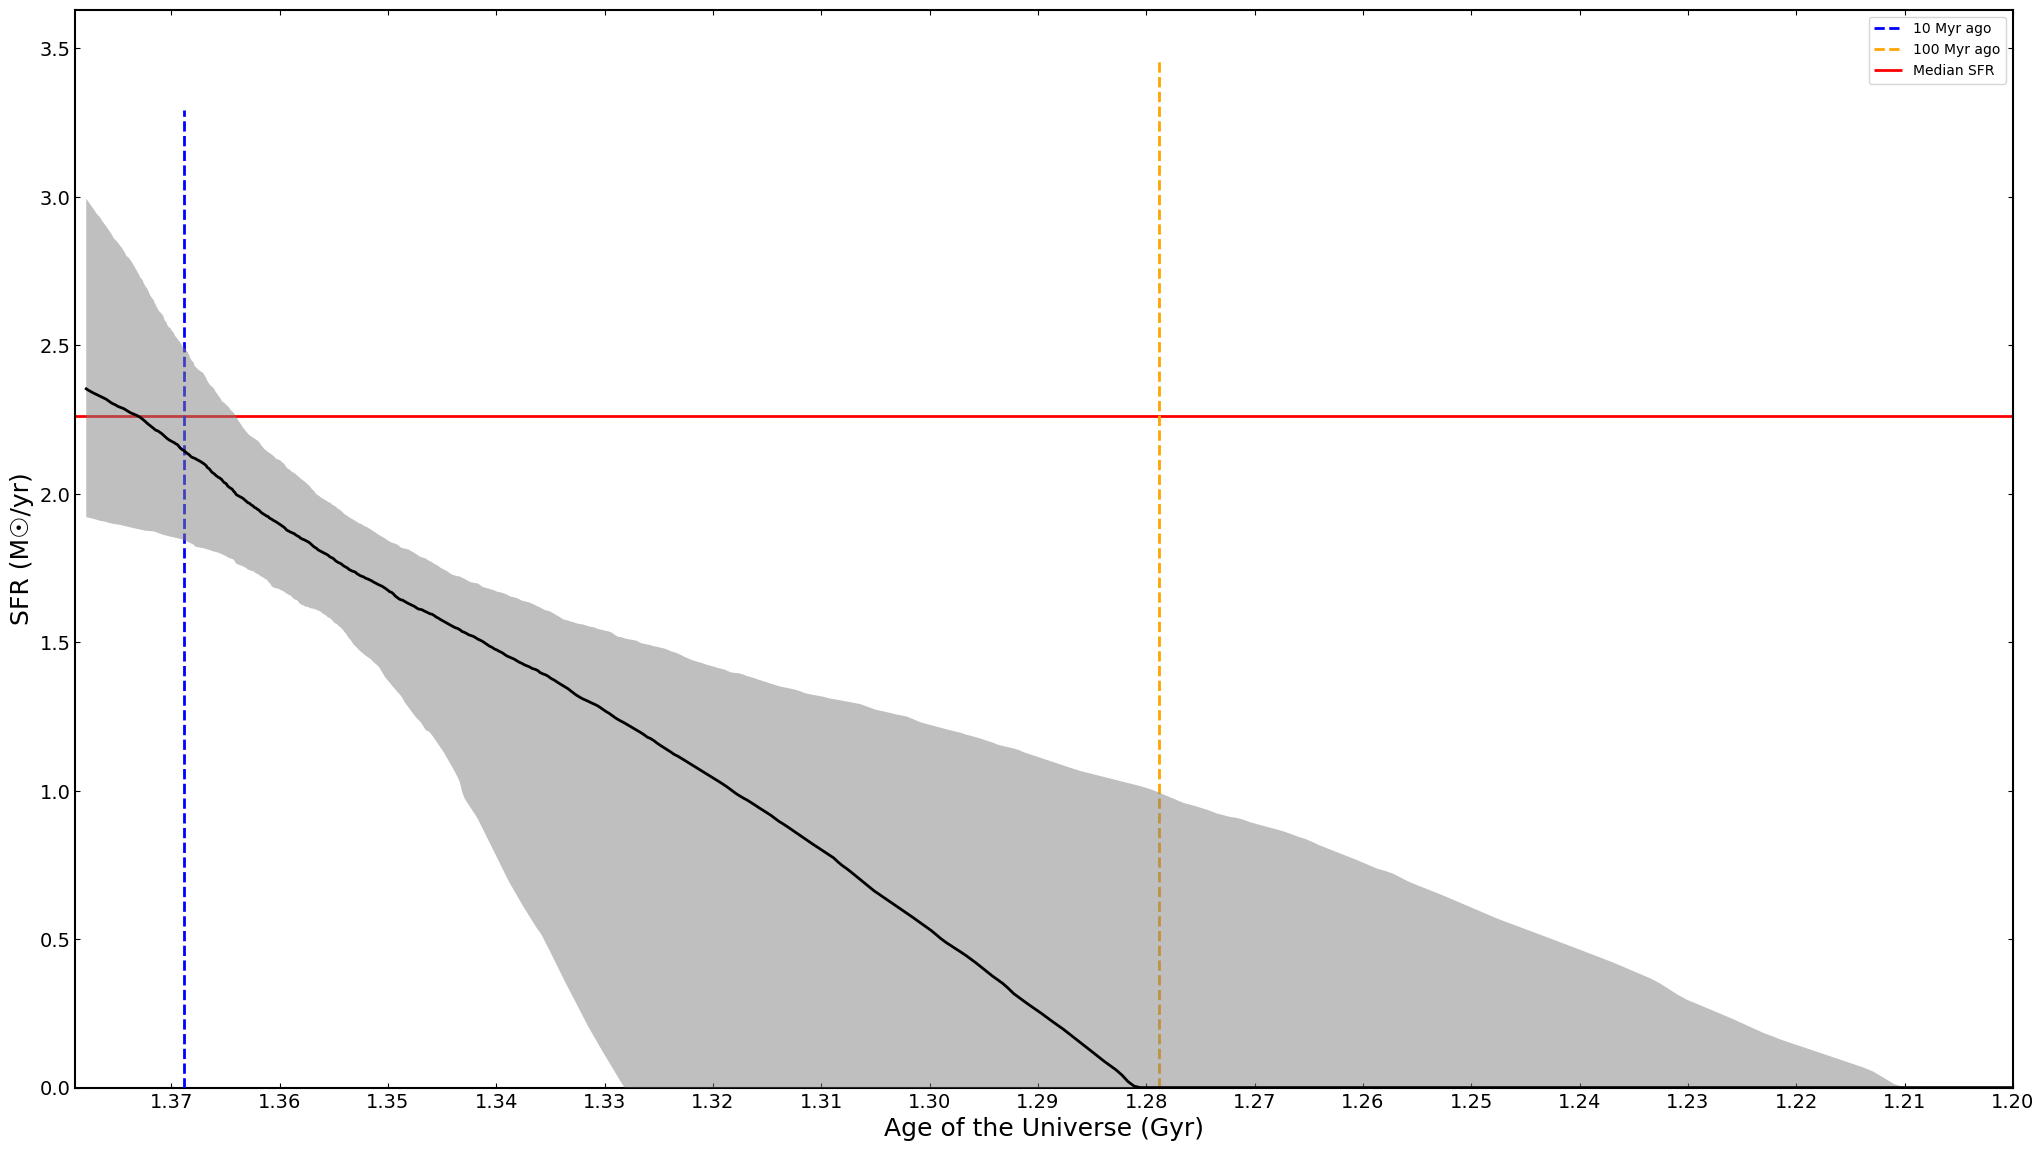

In [223]:
fig, ax = plt.subplots(figsize=(25,14))

x_galaxy_age=age_of_universe - fit.posterior.sfh.ages*10**-9
post = np.percentile(fit.posterior.samples["sfh"], (16, 50, 84), axis=0).T

Time_10Myr=age_of_universe-10**-2
Time_100Myr=age_of_universe-10**-1



ax.plot(x_galaxy_age, post[:, 1], color='k', zorder=5)
ax.vlines(Time_10Myr, 0, np.max([ax.get_ylim()[1], 1.1*np.max(post[:, 2])]), color='blue', ls='--', label='10 Myr ago', zorder=3)
ax.vlines(Time_100Myr, 0, np.max([ax.get_ylim()[1], 1.1*np.max(post[:, 2])]), color='orange', ls='--', label='100 Myr ago', zorder=3)
ax.fill_between(x_galaxy_age, post[:, 0], post[:, 2], color="grey",
                alpha=0.5, zorder=4, lw=0)

ax.set_ylim(0., np.max([ax.get_ylim()[1], 1.1*np.max(post[:, 2])]))
ax.set_xlim(age_of_universe, 1.2)

ax.set_xticks(np.arange(1.2, age_of_universe, 0.01))
ax.set_xlabel("Age of the Universe (Gyr)")
ax.set_ylabel("SFR (M☉/yr)")
ax.hlines(2.26, age_of_universe, 1.2, color='red', ls='-', label='Median SFR')
ax.legend()


In [238]:
time_from_now = 10 * astropy.units.Myr
redshift=np.median(fit.posterior.samples["redshift"])
sfr_ages=fit.posterior.sfh.ages*(astropy.units.yr) # Unit in yr
sfr_values=np.median(fit.posterior.samples["sfh"], axis=0)*(astropy.units.Msun/astropy.units.yr) # Unit in M☉/yr

t_formed = cosmo.age(redshift) - sfr_ages
t_formed=t_formed.to(astropy.units.yr)

def sfr_at_time(t):

    if t < t_formed.value.min() or t > t_formed.value.max():
        return 0.0 * (astropy.units.Msun/astropy.units.yr)  # SFR is zero outside the range of formation times
    else:
        return np.interp(t, t_formed.value[::-1], sfr_values.value[::-1])

target_time = cosmo.age(redshift).to(astropy.units.yr) - time_from_now

stellar_mass_formed=np.trapezoid(sfr_at_time,target_time.to(astropy.units.yr).value, t_formed.max().to(astropy.units.yr).value)[0] * (astropy.units.Msun)

ValueError: diff requires input that is at least one dimensional

In [236]:
stellar_mass_formed/(t_formed.max().to(astropy.units.yr).value-target_time.to(astropy.units.yr).value)

<Quantity 2.24380833 solMass>

In [239]:
import numpy as np
import astropy.units as u

# 1. 定义积分的时间边界（数值）
t_start = target_time.to(u.yr).value
t_end = t_formed.max().to(u.yr).value

# 2. 筛选出落在积分区间内的原始数据点
# 注意：我们使用原始的数组，这样最准确
mask = (t_formed.value >= t_start) & (t_formed.value <= t_end)

t_to_integrate = t_formed.value[mask]
sfr_to_integrate = sfr_values.value[mask]

# 3. 检查是否有足够的数据点进行积分
if len(t_to_integrate) > 1:
    # 重要：np.trapezoid 要求 x 轴（时间）必须是升序排列的
    sort_idx = np.argsort(t_to_integrate)
    x_input = t_to_integrate[sort_idx]
    y_input = sfr_to_integrate[sort_idx]

    # 执行积分
    mass_val = np.trapezoid(y_input, x=x_input)
else:
    # 如果区间太小，没有包含原始点，可以用插值估算一个矩形面积，或者设为0
    mass_val = 0.0

stellar_mass_formed = mass_val * u.Msun

print(f"Stellar mass formed: {stellar_mass_formed:.2e}")

Stellar mass formed: 2.02e+07 solMass


In [237]:
(t_formed.max().to(astropy.units.yr).value-target_time.to(astropy.units.yr).value)

np.float64(9000000.000000238)

In [240]:
print(f"最年轻的 SFH 仓位在: {sfr_ages.min().to(astropy.units.Myr)}")

最年轻的 SFH 仓位在: 1.0 Myr


In [245]:
sfr_ages.to(astropy.units.Myr)

<Quantity [1.00000000e+00, 1.00577306e+00, 1.01157945e+00, ...,
           1.34121994e+04, 1.34896288e+04, 1.35675053e+04] Myr>

In [241]:
import numpy as np
import astropy.units as u

# --- 准备基础数据 ---
t_obs = cosmo.age(redshift).to(u.yr).value
# 原有的 formation times (升序排列)
t_raw = t_formed.value[::-1]
# 原有的 sfr values (对应升序时间)
sfr_raw = sfr_values.value[::-1]

# --- 关键步骤：填充 1Myr 到 0Myr 的空白 ---
# 如果最晚的记录点还没到观测时刻，我们就把观测时刻补上去
if t_raw[-1] < t_obs:
    t_extended = np.append(t_raw, t_obs)
    sfr_extended = np.append(sfr_raw, sfr_raw[-1]) # 假设最近 1Myr 的 SFR 恒定
else:
    t_extended = t_raw
    sfr_extended = sfr_raw

# 定义插值函数（现在它可以覆盖完整的宇宙历史了）
def full_sfr_func(t):
    return np.interp(t, t_extended, sfr_extended)

In [242]:
def calculate_average_sfr(delta_t_myr):
    delta_t_yr = (delta_t_myr * u.Myr).to(u.yr).value
    t_start = t_obs - delta_t_yr
    t_end = t_obs

    # 使用 np.linspace 生成致密网格进行积分（比 quad 稳定）
    t_grid = np.linspace(t_start, t_end, 1000)
    y_grid = full_sfr_func(t_grid)

    # 积分算出这段时间内形成的恒星质量
    mass_formed = np.trapezoid(y_grid, t_grid)

    # 平均 SFR = 总质量 / 时间跨度
    avg_sfr = mass_formed / delta_t_yr
    return avg_sfr * (u.Msun / u.yr)

# --- 直接得出结果 ---
sfr_10 = calculate_average_sfr(10)
sfr_100 = calculate_average_sfr(100)

print(f"SFR_10: {sfr_10:.2f}")
print(f"SFR_100: {sfr_100:.2f}")

SFR_10: 2.27 solMass / yr
SFR_100: 1.20 solMass / yr


In [249]:
from __future__ import print_function, division, absolute_import

import os
import numpy as np
from astropy.cosmology import FlatLambdaCDM



def make_bins(midpoints, make_rhs=False):
    """ A general function for turning an array of bin midpoints into an
    array of bin left hand side positions and bin widths. Splits the
    distance between bin midpoints equally in linear space.

    Parameters
    ----------

    midpoints : numpy.ndarray
        Array of bin midpoint positions

    make_rhs : bool
        Whether to add the position of the right hand side of the final
        bin to bin_lhs, defaults to false.
    """

    bin_widths = np.zeros_like(midpoints)

    if make_rhs:
        bin_lhs = np.zeros(midpoints.shape[0]+1)
        bin_lhs[0] = midpoints[0] - (midpoints[1]-midpoints[0])/2
        bin_widths[-1] = (midpoints[-1] - midpoints[-2])
        bin_lhs[-1] = midpoints[-1] + (midpoints[-1]-midpoints[-2])/2
        bin_lhs[1:-1] = (midpoints[1:] + midpoints[:-1])/2
        bin_widths[:-1] = bin_lhs[1:-1]-bin_lhs[:-2]

    else:
        bin_lhs = np.zeros_like(midpoints)
        bin_lhs[0] = midpoints[0] - (midpoints[1]-midpoints[0])/2
        bin_widths[-1] = (midpoints[-1] - midpoints[-2])
        bin_lhs[1:] = (midpoints[1:] + midpoints[:-1])/2
        bin_widths[:-1] = bin_lhs[1:]-bin_lhs[:-1]

    return bin_lhs, bin_widths


# Set up necessary variables for cosmological calculations.
cosmo = FlatLambdaCDM(H0=70., Om0=0.3)
z_array = np.arange(0., 100., 0.01)
age_at_z = cosmo.age(z_array).value
ldist_at_z = cosmo.luminosity_distance(z_array).value



In [250]:
hubble_time = cosmo.age(0).value
log_sampling=0.0025
log_age_max = np.log10(hubble_time)+9. + 2*log_sampling

In [251]:
ages = np.arange(6., log_age_max, log_sampling)
age_lhs = make_bins(ages, make_rhs=True)[0]
ages = 10**ages
age_lhs = 10**age_lhs
age_lhs[0] = 0.
age_lhs[-1] = 10**9*hubble_time
age_widths = age_lhs[1:] - age_lhs[:-1]

In [260]:
(age_widths/1000000)[0:2]

array([1.00288238, 0.0057897 ])